# 🔍 Anomaly Explorer — Grand River Water Quality

This notebook explores the anomaly detection results from our Isolation Forest model.

**Data source:** Ontario Provincial Water Quality Monitoring Network (PWQMN)  
**Watershed:** Grand River — 8 stations within 45 km of Six Nations  
**Period:** 2019–2024 (5 years)  
**Model:** Isolation Forest (contamination=5%, 200 trees)

### What you'll see:
1. Overview of the data and anomaly distribution
2. Which stations and parameters flag the most
3. Time series with anomalies highlighted
4. Top anomalies ranked by severity
5. Feature correlations driving the model

In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_columns", 20)

# Navigate to project root
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", ".."))

# Station name lookup (distance from Six Nations)
STATION_NAMES = {
    16018412802: "Big Creek @ Hwy 54 (4.3 km)",
    16018409202: "Grand River @ York (13.5 km)",
    16018409302: "Fairchild Creek @ Harris Rd (14 km)",
    16018402702: "Grand River @ Brantford (16.8 km)",
    16018400902: "Nith River @ Paris (30.8 km)",
    16018401002: "Grand River @ Glen Morris (34.1 km)",
    16018403502: "Grand River @ Dunnville (39.2 km)",
    16018401202: "Grand River @ Blair (45.5 km)",
}

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load the Data

We load two files:
- **anomalies.csv** — model output with anomaly scores and flags
- **grand_river_features.csv** — the engineered features fed to the model

In [2]:
# Load anomaly results and features
anomalies = pd.read_csv("outputs/anomalies.csv", parse_dates=["timestamp"])
features = pd.read_csv("data/processed/grand_river_features.csv", parse_dates=["timestamp"])

# Add readable station names
anomalies["station_name"] = anomalies["station_id"].map(STATION_NAMES)
features["station_name"] = features["station_id"].map(STATION_NAMES)

print(f"Anomalies: {anomalies.shape[0]:,} rows, {anomalies.shape[1]} columns")
print(f"Features:  {features.shape[0]:,} rows, {features.shape[1]} columns")
print(f"\nAnomalies flagged: {anomalies.is_anomaly.sum()} / {len(anomalies)} ({anomalies.is_anomaly.mean():.1%})")

Anomalies: 13,194 rows, 8 columns
Features:  13,194 rows, 20 columns

Anomalies flagged: 660 / 13194 (5.0%)


## 2. Data Overview — First & Last Rows

In [3]:
print("=== First 5 rows ===")
display(anomalies.head())

print("\n=== Last 5 rows ===")
display(anomalies.tail())

=== First 5 rows ===


,station_id,timestamp,parameter,value,unit,anomaly_score,is_anomaly,station_name
0,16018400902,2019-04-08 14:30:00,"AMMONIUM, TOTAL UNFIL.REAC",0.048,mg/L,0.0389,0,Nith River @ Paris (30.8 km)
1,16018400902,2019-04-08 14:30:00,"CHLORIDE, UNFIL.REAC",38.000,mg/L,0.0779,0,Nith River @ Paris (30.8 km)
2,16018400902,2019-04-08 14:30:00,"CONDUCTIVITY, AMBIENT",682.000,MICROMHOS/CM (CONDUCTIVITY),0.4938,0,Nith River @ Paris (30.8 km)
3,16018400902,2019-04-08 14:30:00,DISSOLVED OXYGEN,11.180,mg/L,0.0488,0,Nith River @ Paris (30.8 km)
4,16018400902,2019-04-08 14:30:00,"NITRATES TOTAL, UNFIL.REAC",4.930,mg/L,0.0379,0,Nith River @ Paris (30.8 km)



=== Last 5 rows ===


,station_id,timestamp,parameter,value,unit,anomaly_score,is_anomaly,station_name
13189,16018412802,2024-11-12 10:41:00,NITROGEN; TOTAL,0.652,mg/L,0.0375,0,Big Creek @ Hwy 54 (4.3 km)
13190,16018412802,2024-11-12 10:41:00,PH,8.260,NaN,0.0223,0,Big Creek @ Hwy 54 (4.3 km)
13191,16018412802,2024-11-12 10:41:00,PHOSPHORUS; PHOSPHATE,0.038,mg/L,0.0064,0,Big Creek @ Hwy 54 (4.3 km)
13192,16018412802,2024-11-12 10:41:00,PHOSPHORUS; TOTAL,73.100,µg/L,0.2654,0,Big Creek @ Hwy 54 (4.3 km)
13193,16018412802,2024-11-12 10:41:00,SOLIDS; SUSPENDED,14.900,mg/L,0.0920,0,Big Creek @ Hwy 54 (4.3 km)


## 3. Data Shape & Types

In [4]:
print(f"Shape: {anomalies.shape}")
print(f"\nDate range: {anomalies.timestamp.min()} → {anomalies.timestamp.max()}")
print(f"Unique stations: {anomalies.station_id.nunique()}")
print(f"Unique parameters: {anomalies.parameter.nunique()}")
print(f"\n--- Column types ---")
print(anomalies.dtypes)

Shape: (13194, 8)

Date range: 2019-01-15 14:58:00 → 2024-12-10 13:10:00
Unique stations: 8
Unique parameters: 103

--- Column types ---
station_id                int64
timestamp        datetime64[ns]
parameter                object
value                   float64
unit                     object
anomaly_score           float64
is_anomaly                int64
station_name             object
dtype: object


## 4. Descriptive Statistics

In [5]:
# Summary stats for numeric columns
display(anomalies[["value", "anomaly_score"]].describe())

print("\n--- Anomaly score distribution ---")
print(f"  Mean:   {anomalies.anomaly_score.mean():.4f}")
print(f"  Median: {anomalies.anomaly_score.median():.4f}")
print(f"  95th %: {anomalies.anomaly_score.quantile(0.95):.4f}")
print(f"  99th %: {anomalies.anomaly_score.quantile(0.99):.4f}")
print(f"  Max:    {anomalies.anomaly_score.max():.4f}")

,value,anomaly_score
count,13194.000000,13194.000000
mean,90.014197,0.154513
std,229.714302,0.184824
min,-14.300000,0.000000
25%,1.210000,0.024200
50%,6.005000,0.074300
75%,48.300000,0.210950
max,10900.000000,1.000000



--- Anomaly score distribution ---
  Mean:   0.1545
  Median: 0.0743
  95th %: 0.5827
  99th %: 0.7386
  Max:    1.0000


## 5. Missing Values Check

In [6]:
# Check for missing values in anomaly output
missing = anomalies.isnull().sum()
print("Missing values per column:")
has_missing = missing[missing > 0]
print(has_missing if len(has_missing) > 0 else "✅ No missing values in anomaly output")

print("\n--- Feature NaN check (input to model) ---")
feat_missing = features.isnull().sum()
feat_pct = (feat_missing / len(features) * 100).round(2)
feat_report = pd.DataFrame({"missing": feat_missing, "pct": feat_pct})
display(feat_report[feat_report.missing > 0])

Missing values per column:
unit    252
dtype: int64

--- Feature NaN check (input to model) ---


,missing,pct
unit,252,1.91
qualifier,10833,82.11
qa_status,13194,100.00
delta,588,4.46
time_gap_days,588,4.46
rate_of_change,588,4.46
rolling_std_7,588,4.46
rolling_std_14,588,4.46
rolling_std_30,588,4.46
zscore,1622,12.29


## 6. Anomaly Rate by Station

Which stations flag the most anomalies? Stations closer to industrial or agricultural activity should show higher rates.

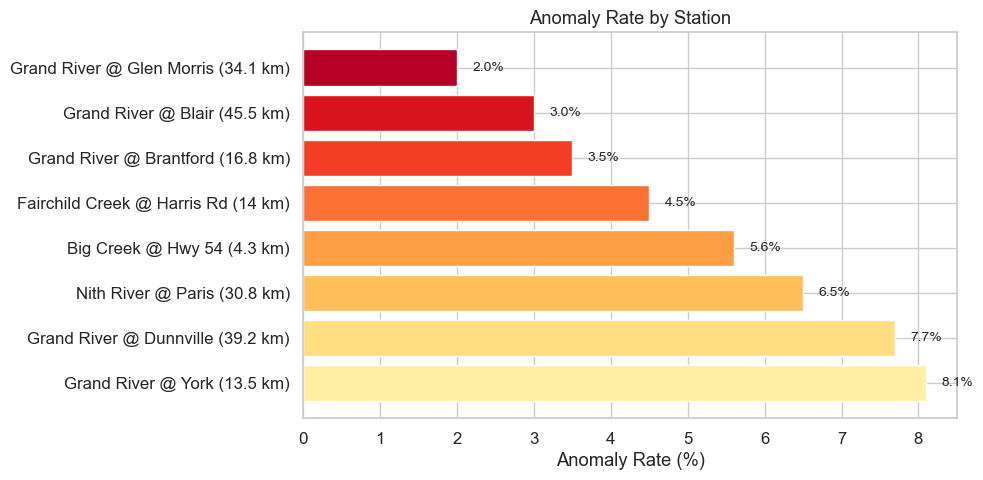

,total,anomalies,mean_score,max_score,rate
station_name,,,,,
Grand River @ York (13.5 km),627,51,0.201775,1.0000,8.1
Grand River @ Dunnville (39.2 km),3665,284,0.155714,0.8891,7.7
Nith River @ Paris (30.8 km),751,49,0.191968,0.7928,6.5
Big Creek @ Hwy 54 (4.3 km),571,32,0.181337,0.7730,5.6
Fairchild Creek @ Harris Rd (14 km),1861,83,0.159197,0.9588,4.5
Grand River @ Brantford (16.8 km),1910,66,0.143930,0.9018,3.5
Grand River @ Blair (45.5 km),1925,58,0.144442,0.9517,3.0
Grand River @ Glen Morris (34.1 km),1884,37,0.129776,0.7965,2.0


In [7]:
# Anomaly rate per station
station_stats = (
    anomalies.groupby("station_name")
    .agg(
        total=("is_anomaly", "count"),
        anomalies=("is_anomaly", "sum"),
        mean_score=("anomaly_score", "mean"),
        max_score=("anomaly_score", "max"),
    )
    .assign(rate=lambda d: (d.anomalies / d.total * 100).round(1))
    .sort_values("rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(station_stats.index, station_stats["rate"],
               color=sns.color_palette("YlOrRd", len(station_stats)))
ax.set_xlabel("Anomaly Rate (%)")
ax.set_title("Anomaly Rate by Station")
for bar, val in zip(bars, station_stats["rate"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

display(station_stats)

## 7. Top Anomalous Parameters

Which water quality parameters trigger the most anomaly flags? These are the measurements behaving most unusually.

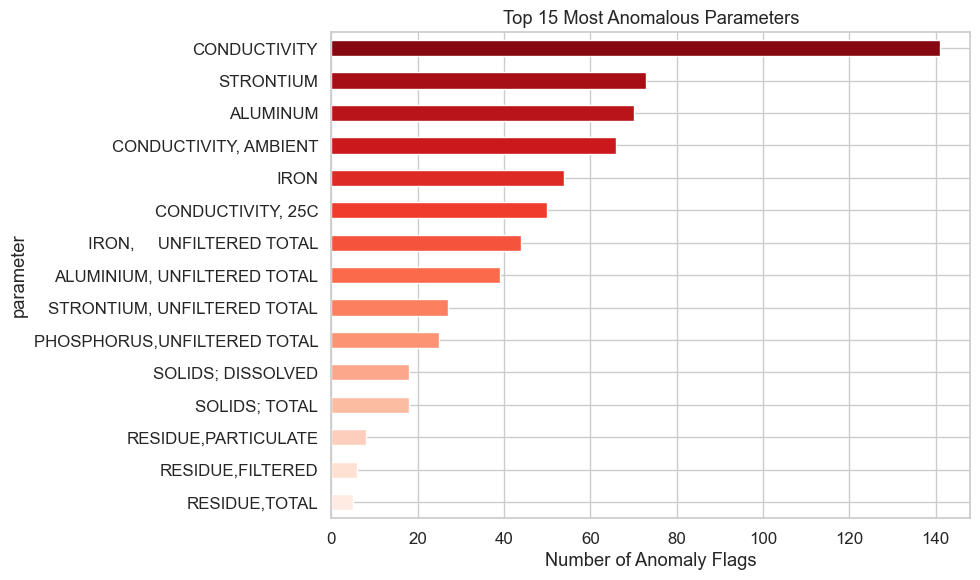

In [8]:
# Top 15 parameters by anomaly count
anom_only = anomalies[anomalies.is_anomaly == 1]
param_counts = anom_only["parameter"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
param_counts.plot.barh(ax=ax, color=sns.color_palette("Reds_r", len(param_counts)))
ax.set_xlabel("Number of Anomaly Flags")
ax.set_title("Top 15 Most Anomalous Parameters")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Top 20 Anomalies Ranked by Severity

The most extreme readings the model found — sorted by anomaly score (1.0 = most extreme).

In [9]:
# Top 20 most anomalous readings
top20 = (
    anomalies[anomalies.is_anomaly == 1]
    .nlargest(20, "anomaly_score")
    [["station_name", "timestamp", "parameter", "value", "unit", "anomaly_score"]]
    .reset_index(drop=True)
)
top20.index = top20.index + 1  # 1-based ranking
display(top20)

,station_name,timestamp,parameter,value,unit,anomaly_score
1,Grand River @ York (13.5 km),2021-01-27 10:10:00,"CONDUCTIVITY, AMBIENT",10900.0,MICROMHOS/CM (CONDUCTIVITY),1.0000
2,Grand River @ York (13.5 km),2021-02-23 10:40:00,"CONDUCTIVITY, AMBIENT",1208.0,MICROMHOS/CM (CONDUCTIVITY),0.9641
3,Fairchild Creek @ Harris Rd (14 km),2019-09-11 09:50:00,"IRON, UNFILTERED TOTAL",3580.0,µg/L,0.9588
4,Fairchild Creek @ Harris Rd (14 km),2020-10-08 10:05:00,"IRON, UNFILTERED TOTAL",486.0,µg/L,0.9563
5,Fairchild Creek @ Harris Rd (14 km),2019-10-09 10:05:00,"IRON, UNFILTERED TOTAL",559.0,µg/L,0.9556
6,Grand River @ Blair (45.5 km),2019-06-13 10:00:00,"IRON, UNFILTERED TOTAL",142.0,µg/L,0.9517
7,Fairchild Creek @ Harris Rd (14 km),2020-01-13 10:34:00,"IRON, UNFILTERED TOTAL",973.0,µg/L,0.9371
8,Fairchild Creek @ Harris Rd (14 km),2019-09-11 09:50:00,"ALUMINIUM, UNFILTERED TOTAL",2330.0,µg/L,0.9318
9,Fairchild Creek @ Harris Rd (14 km),2019-10-09 10:05:00,"ALUMINIUM, UNFILTERED TOTAL",350.0,µg/L,0.9318
10,Fairchild Creek @ Harris Rd (14 km),2020-01-13 10:34:00,"ALUMINIUM, UNFILTERED TOTAL",1040.0,µg/L,0.9314


## 9. Anomaly Score Distribution

Most readings cluster near 0 (normal). The tail extending toward 1.0 contains our anomalies.

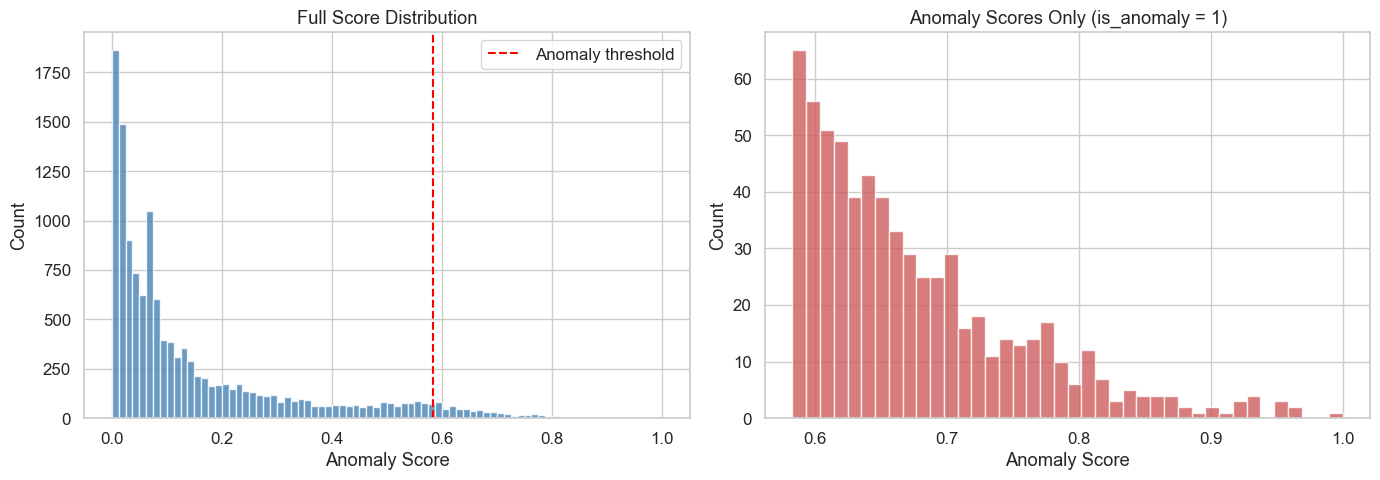

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(anomalies["anomaly_score"], bins=80, color="steelblue",
             edgecolor="white", alpha=0.8)
threshold = anomalies[anomalies.is_anomaly == 1]["anomaly_score"].min()
axes[0].axvline(threshold, color="red", linestyle="--", label="Anomaly threshold")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Full Score Distribution")
axes[0].legend()

# Zoomed: anomalies only
axes[1].hist(anom_only["anomaly_score"], bins=40, color="indianred",
             edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Anomaly Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Anomaly Scores Only (is_anomaly = 1)")

plt.tight_layout()
plt.show()

## 10. Time Series — Anomalies Over Time

Visualize readings over time with anomalies shown as red dots. The first plot shows the #1 anomaly: Conductivity at York.

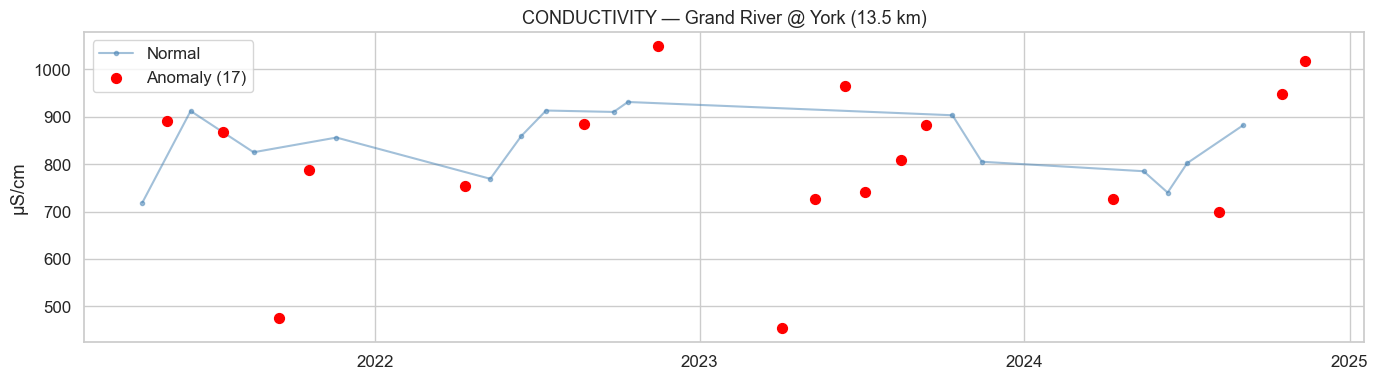

In [11]:
def plot_timeseries(df, station_name, parameter):
    """Plot a single station+parameter time series with anomalies highlighted."""
    mask = (df.station_name == station_name) & (df.parameter == parameter)
    subset = df[mask].sort_values("timestamp")

    if len(subset) == 0:
        print(f"No data for {station_name} / {parameter}")
        return

    normal = subset[subset.is_anomaly == 0]
    flagged = subset[subset.is_anomaly == 1]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(normal.timestamp, normal.value, "o-", ms=3, alpha=0.5,
            color="steelblue", label="Normal")
    if len(flagged) > 0:
        ax.scatter(flagged.timestamp, flagged.value, c="red", s=50,
                   zorder=5, label=f"Anomaly ({len(flagged)})")
    ax.set_title(f"{parameter} — {station_name}", fontsize=13)
    ax.set_ylabel(subset.unit.iloc[0] if "unit" in subset.columns else "Value")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- Plot the #1 anomaly: Conductivity at York ---
plot_timeseries(anomalies, "Grand River @ York (13.5 km)", "CONDUCTIVITY")

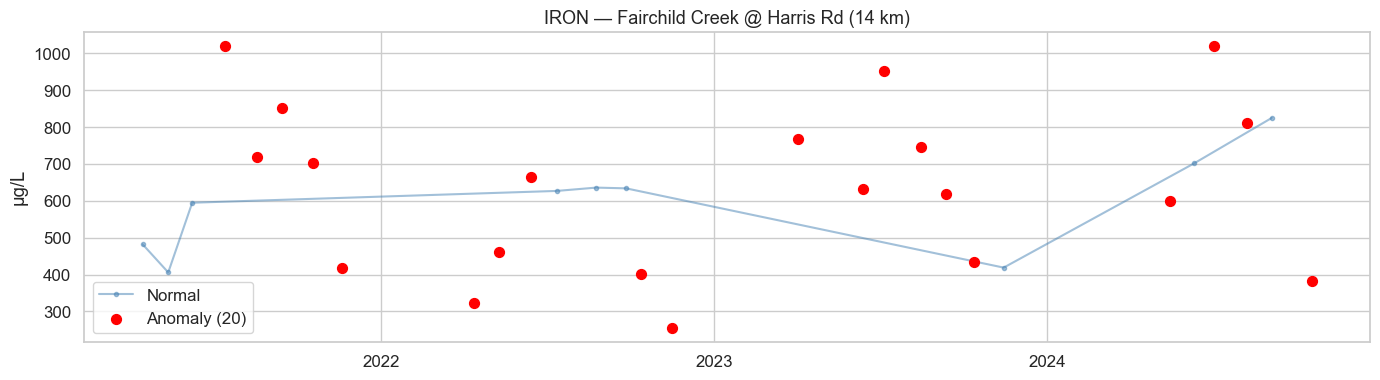

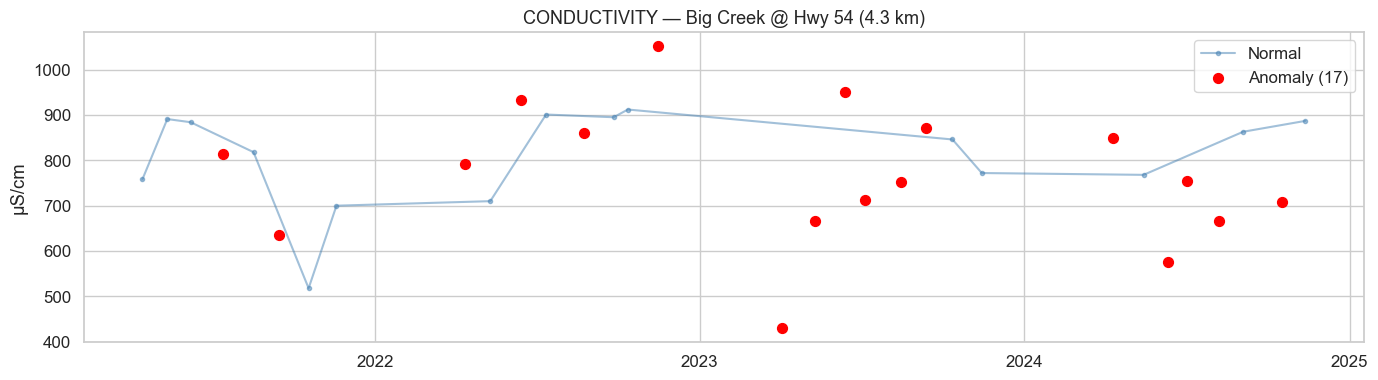

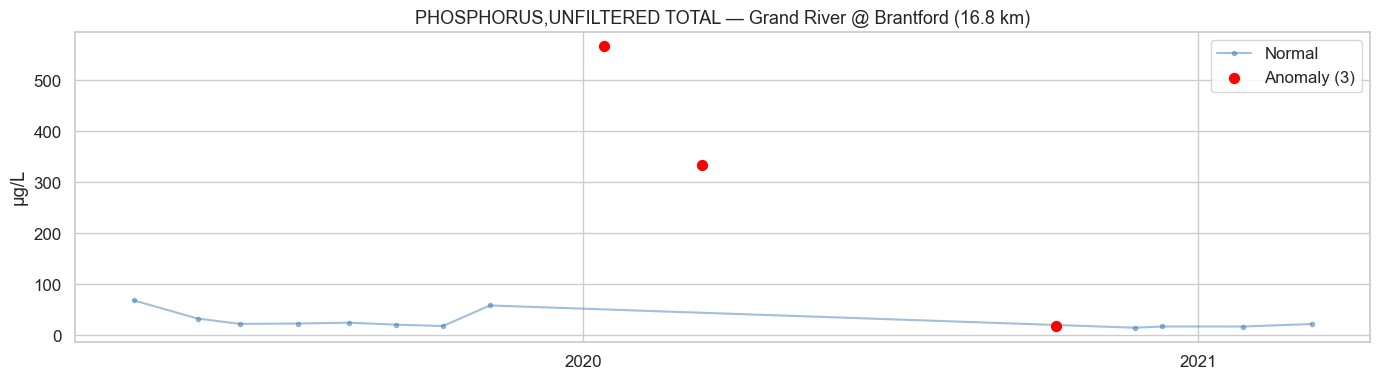

In [12]:
# --- More examples: key parameters at key stations ---
plot_timeseries(anomalies, "Fairchild Creek @ Harris Rd (14 km)", "IRON")
plot_timeseries(anomalies, "Big Creek @ Hwy 54 (4.3 km)", "CONDUCTIVITY")
plot_timeseries(anomalies, "Grand River @ Brantford (16.8 km)", "PHOSPHORUS,UNFILTERED TOTAL")

## 11. Anomalies by Month — Seasonal Pattern?

Spring runoff and summer low-flow often drive spikes. Let's see if anomalies cluster seasonally.

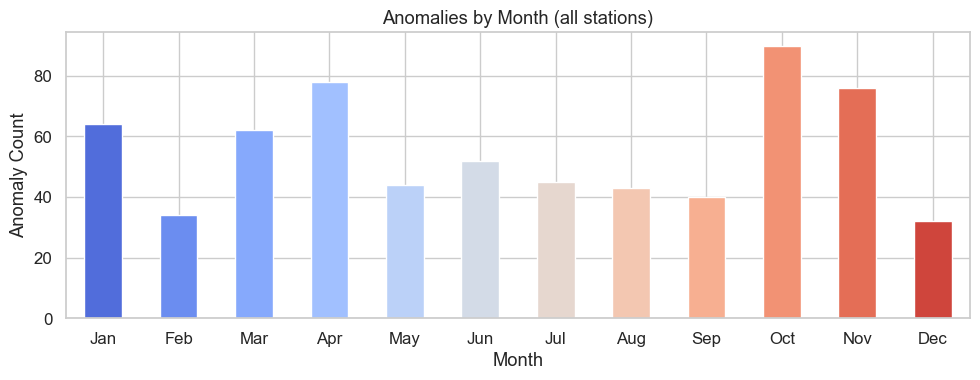

In [13]:
anom_monthly = anom_only.copy()
anom_monthly["month"] = anom_monthly.timestamp.dt.month
month_counts = anom_monthly.groupby("month").size()

fig, ax = plt.subplots(figsize=(10, 4))
month_counts.plot.bar(ax=ax, color=sns.color_palette("coolwarm", 12))
ax.set_xlabel("Month")
ax.set_ylabel("Anomaly Count")
ax.set_title("Anomalies by Month (all stations)")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.show()

## 12. Scatter Plot — Anomaly Score vs. Z-Score

The z-score measures how far a reading is from its rolling mean. Higher z-scores often correspond to higher anomaly scores — but the Isolation Forest considers all 11 features together, so it's not a 1:1 relationship.

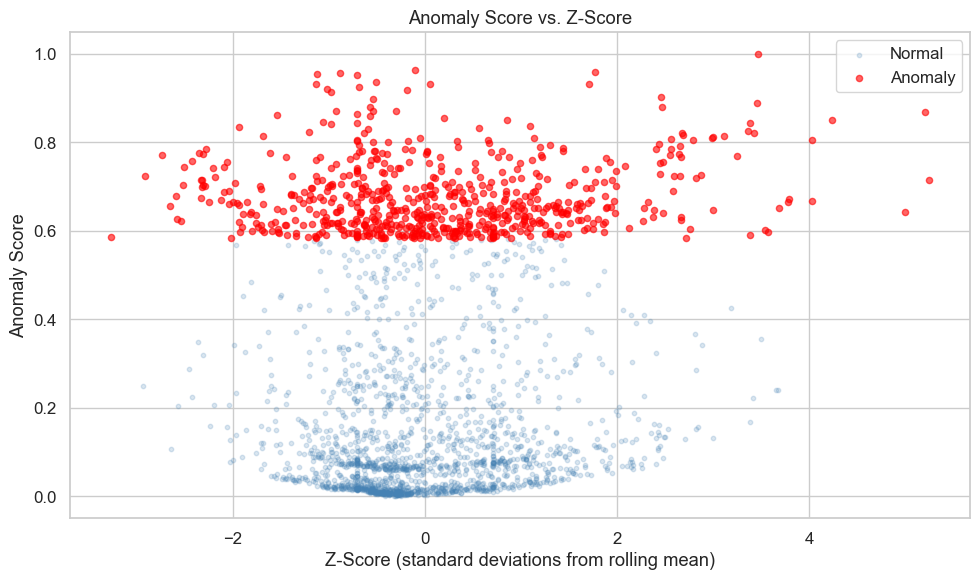

In [14]:
# Merge features with anomaly scores for scatter analysis
merged = anomalies.merge(
    features[["station_id", "timestamp", "parameter",
              "zscore", "delta", "rate_of_change", "time_gap_days"]],
    on=["station_id", "timestamp", "parameter"],
    how="left"
)

fig, ax = plt.subplots(figsize=(10, 6))
normal_m = merged[merged.is_anomaly == 0].sample(
    min(2000, len(merged[merged.is_anomaly == 0])), random_state=42)
anom_m = merged[merged.is_anomaly == 1]

ax.scatter(normal_m.zscore, normal_m.anomaly_score, alpha=0.2, s=10,
           color="steelblue", label="Normal")
ax.scatter(anom_m.zscore, anom_m.anomaly_score, alpha=0.6, s=20,
           color="red", label="Anomaly")
ax.set_xlabel("Z-Score (standard deviations from rolling mean)")
ax.set_ylabel("Anomaly Score")
ax.set_title("Anomaly Score vs. Z-Score")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Box Plots — Score Distribution by Station

How does the anomaly score spread differ across stations?

C:\Users\mdent\AppData\Local\Temp\ipykernel_23968\418334462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=anomalies, x="station_name", y="anomaly_score",
C:\Users\mdent\AppData\Local\Temp\ipykernel_23968\418334462.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)


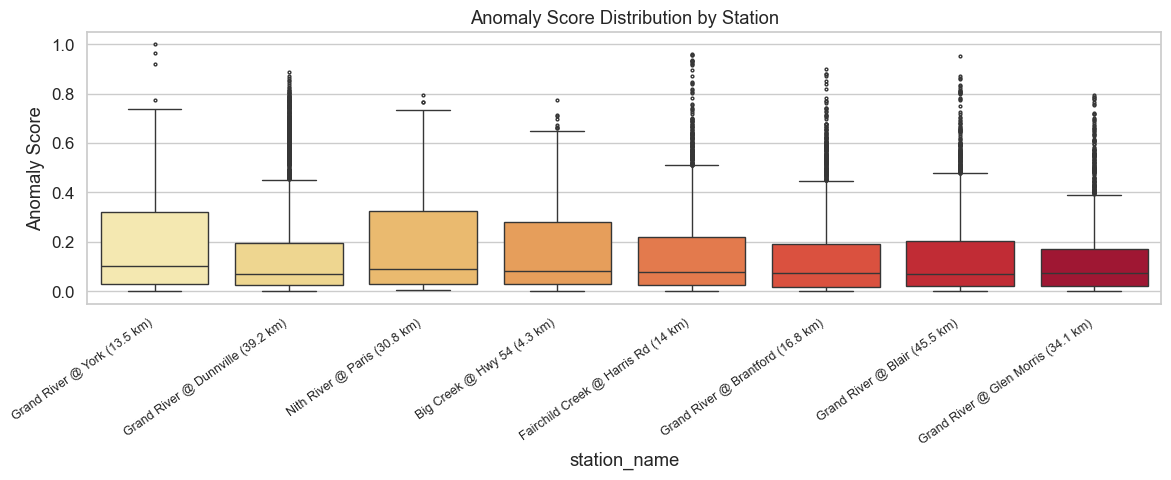

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
order = station_stats.index.tolist()  # sorted by anomaly rate
sns.boxplot(data=anomalies, x="station_name", y="anomaly_score",
            order=order, hue="station_name", hue_order=order,
            ax=ax, palette="YlOrRd", fliersize=2, legend=False)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Anomaly Score")
ax.set_title("Anomaly Score Distribution by Station")
plt.tight_layout()
plt.show()

## 14. Feature Correlation Heatmap

How do the 11 engineered features relate to each other? Strong correlations help us understand what the model "sees."

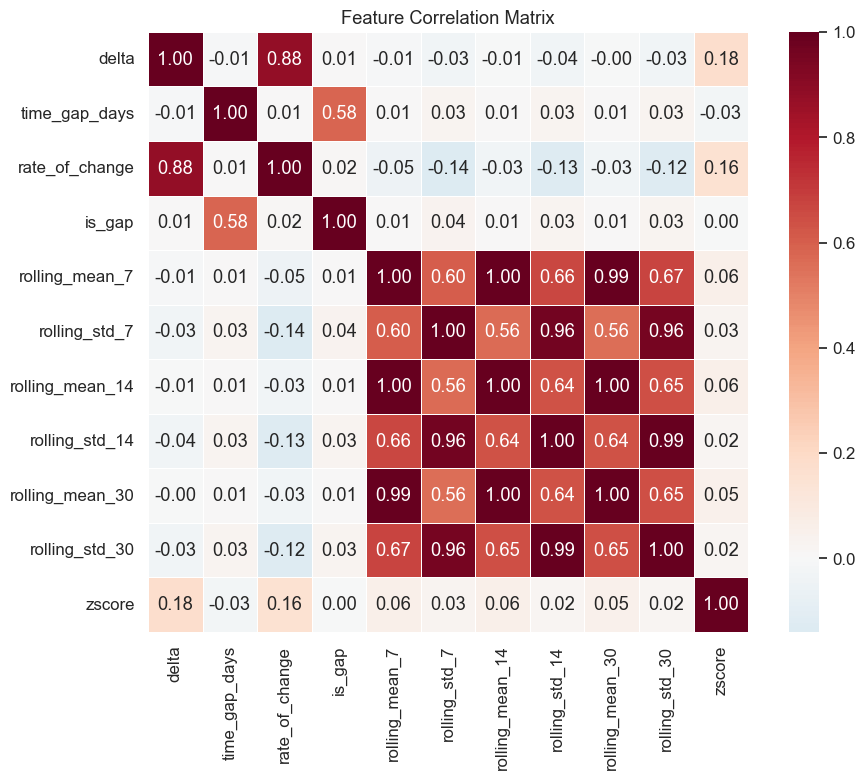

In [16]:
feature_cols = [
    "delta", "time_gap_days", "rate_of_change", "is_gap",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "rolling_mean_30", "rolling_std_30",
    "zscore"
]
corr = features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 15. Explore Any Station + Parameter

Change `STATION` and `PARAM` below to explore any combination interactively.

Station:   Big Creek @ Hwy 54 (4.3 km)
Parameter: CONDUCTIVITY
Readings:  32, Anomalies: 17
Range:     431.0 – 1052.0 µS/cm



,timestamp,value,unit,anomaly_score,is_anomaly
0,2021-04-14 10:30:00,758.0,µS/cm,0.5198,0
1,2021-05-12 10:30:00,891.0,µS/cm,0.5732,0
2,2021-06-07 16:43:00,884.0,µS/cm,0.5485,0
3,2021-07-13 15:05:00,813.0,µS/cm,0.6259,1
4,2021-08-17 10:30:00,818.0,µS/cm,0.5488,0
5,2021-09-14 16:32:00,635.0,µS/cm,0.6084,1
6,2021-10-18 08:52:00,518.0,µS/cm,0.5786,0
7,2021-11-18 16:20:00,700.0,µS/cm,0.5756,0
8,2022-04-12 13:22:00,791.0,µS/cm,0.6302,1
9,2022-05-10 16:32:00,710.0,µS/cm,0.5155,0


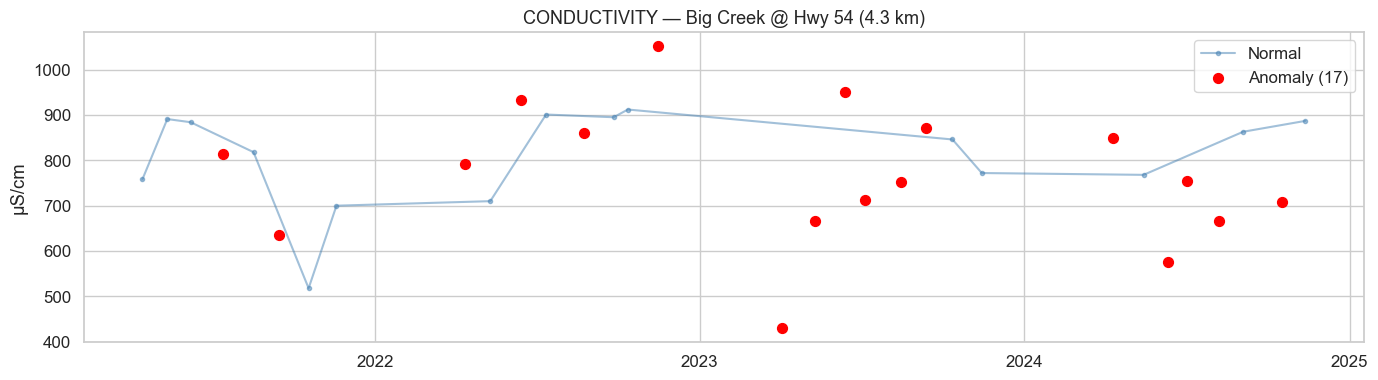

In [17]:
# --- Change these to explore different combinations ---
STATION = "Big Creek @ Hwy 54 (4.3 km)"   # Closest station to Six Nations
PARAM = "CONDUCTIVITY"

# Filter and display
subset = anomalies[
    (anomalies.station_name == STATION) & (anomalies.parameter == PARAM)
].sort_values("timestamp")

print(f"Station:   {STATION}")
print(f"Parameter: {PARAM}")
print(f"Readings:  {len(subset)}, Anomalies: {subset.is_anomaly.sum()}")
if len(subset) > 0:
    print(f"Range:     {subset.value.min():.1f} – {subset.value.max():.1f} {subset.unit.iloc[0]}")
    print()
    display(subset[["timestamp", "value", "unit", "anomaly_score", "is_anomaly"]].reset_index(drop=True))

    # Plot it
    plot_timeseries(anomalies, STATION, PARAM)

## Summary

| Metric | Value |
|--------|-------|
| Total readings | 13,194 |
| Anomalies flagged | 660 (5.0%) |
| Stations | 8 (within 45 km of Six Nations) |
| Top anomalous param | CONDUCTIVITY |
| Top anomalous station | Grand River @ York (8.1%) |
| Closest station | Big Creek @ Hwy 54 (4.3 km) |
| Model | Isolation Forest (unsupervised) |

**Key insight:** The model correctly flags real water quality events — conductivity spikes (possible salt/industrial discharge), metal surges (iron, aluminium from runoff), and nutrient spikes (phosphorus) — without being told what "bad" looks like.

**Next:** Day 9 will add **driver hints** — for each anomaly, the top 3 features that made the model flag it.